In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (10000, 14)

Columns:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Data Types:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Missing Values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Mac

In [3]:
print("Machine Failure Distribution:")
print(df["Machine failure"].value_counts())

print("\nMachine Failure Percentage:")
print(df["Machine failure"].value_counts(normalize=True) * 100)

failure_types = ["TWF", "HDF", "PWF", "OSF", "RNF"]

print("\nFailure Types:")
for failure in failure_types:
    print(f"{failure}: {df[failure].sum()}")

Machine Failure Distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine Failure Percentage:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

Failure Types:
TWF: 46
HDF: 115
PWF: 95
OSF: 98
RNF: 19


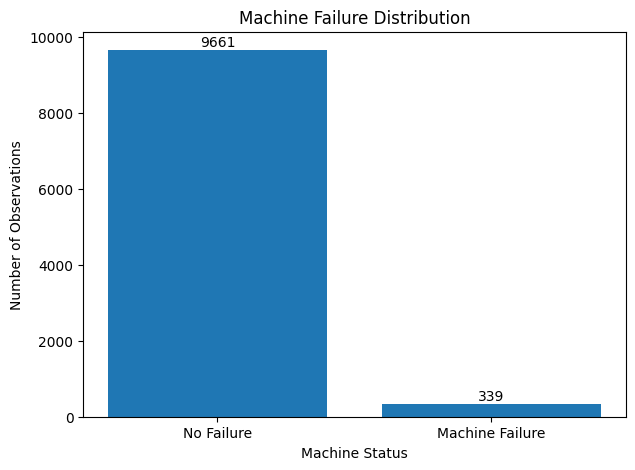

In [4]:
import matplotlib.pyplot as plt

failure_counts = df["Machine failure"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["No Failure", "Machine Failure"],
    failure_counts.values
)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Status")
plt.ylabel("Number of Observations")

for i, value in enumerate(failure_counts.values):
    plt.text(i, value + 100, str(value), ha="center")

plt.show()

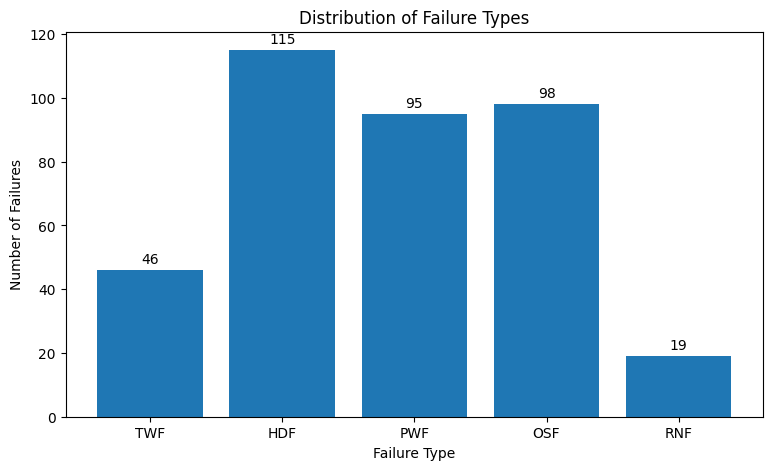

In [5]:
failure_types = ["TWF", "HDF", "PWF", "OSF", "RNF"]

failure_type_counts = df[failure_types].sum()

plt.figure(figsize=(9, 5))

plt.bar(
    failure_type_counts.index,
    failure_type_counts.values
)

plt.title("Distribution of Failure Types")
plt.xlabel("Failure Type")
plt.ylabel("Number of Failures")

for i, value in enumerate(failure_type_counts.values):
    plt.text(i, value + 2, str(value), ha="center")

plt.show()

In [6]:
sensor_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

sensor_comparison = (
    df.groupby("Machine failure")[sensor_columns]
    .mean()
    .T
)

sensor_comparison.columns = ["No Failure", "Failure"]

sensor_comparison

,No Failure,Failure
Air temperature [K],299.973999,300.886431
Process temperature [K],309.995570,310.290265
Rotational speed [rpm],1540.260014,1496.486726
Torque [Nm],39.629655,50.168142
Tool wear [min],106.693717,143.781711


In [7]:
correlation_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Machine failure"
]

correlation_matrix = df[correlation_features].corr()

correlation_matrix

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
Machine failure,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


In [8]:
failure_correlation = (
    correlation_matrix["Machine failure"]
    .drop("Machine failure")
    .sort_values(key=abs, ascending=False)
)

print("Correlation with Machine Failure:")
print(failure_correlation)

Correlation with Machine Failure:
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Rotational speed [rpm]    -0.044188
Process temperature [K]    0.035946
Name: Machine failure, dtype: float64


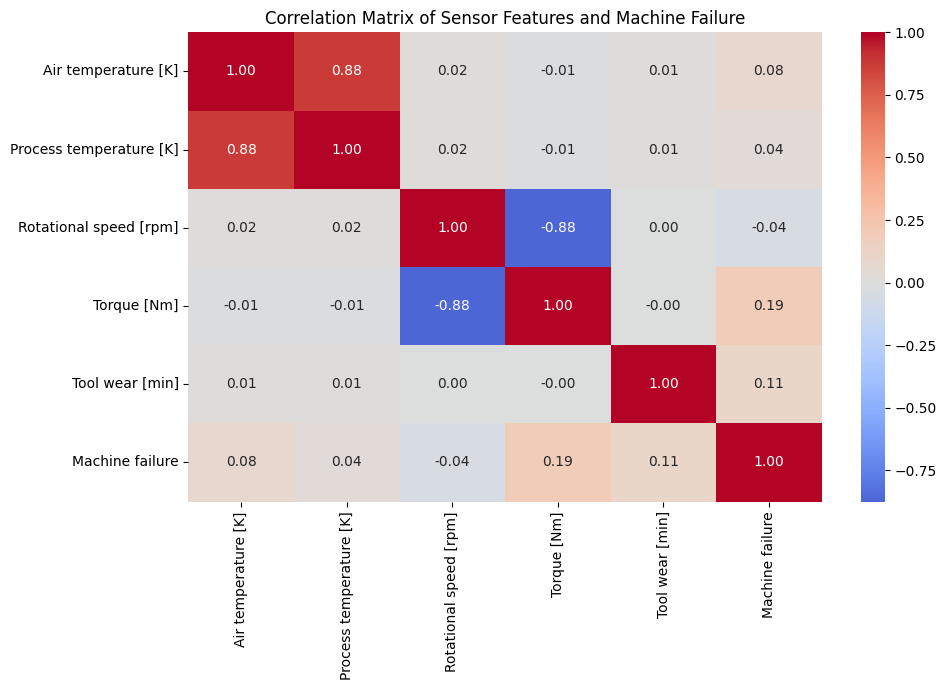

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Sensor Features and Machine Failure")
plt.tight_layout()
plt.show()

In [10]:
# Temperature difference
df["Temperature Difference [K]"] = (
    df["Process temperature [K]"]
    - df["Air temperature [K]"]
)

# Approximate mechanical power in Watts
df["Power [W]"] = (
    df["Torque [Nm]"]
    * df["Rotational speed [rpm]"]
    * 2 * np.pi / 60
)

# Experimental load-wear interaction feature
df["Strain"] = (
    df["Torque [Nm]"]
    * df["Tool wear [min]"]
)

df[
    [
        "Temperature Difference [K]",
        "Power [W]",
        "Strain"
    ]
].describe()

,Temperature Difference [K],Power [W],Strain
count,10000.000000,10000.000000,10000.000000
mean,10.000630,6279.744953,4314.664550
std,1.001094,1067.418295,2826.567692
min,7.600000,1148.440610,0.000000
25%,9.300000,5561.184484,1963.650000
50%,9.800000,6271.027344,4012.950000
75%,11.000000,7003.002724,6279.000000
max,12.100000,10469.923005,16497.000000


In [11]:
# Rename the engineered interaction feature
df = df.rename(
    columns={"Strain": "Torque_Wear_Interaction"}
)

features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature Difference [K]",
    "Power [W]",
    "Torque_Wear_Interaction"
]

X = df[features].copy()
y = df["Machine failure"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (10000, 9)
y shape: (10000,)

Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split

# One-Hot Encoding for machine type
X_encoded = pd.get_dummies(
    X,
    columns=["Type"],
    drop_first=False,
    dtype=int
)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Encoded Features:")
print(X_encoded.columns.tolist())

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Encoded Features:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature Difference [K]', 'Power [W]', 'Torque_Wear_Interaction', 'Type_H', 'Type_L', 'Type_M']

Training Shape: (8000, 11)
Testing Shape: (2000, 11)

Training Target Distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Testing Target Distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Baseline")
print("-" * 40)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Baseline
----------------------------------------
Accuracy:  0.9925
Precision: 0.9649
Recall:    0.8088
F1 Score:  0.8800

Confusion Matrix:
[[1930    2]
 [  13   55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.96      0.81      0.88        68

    accuracy                           0.99      2000
   macro avg       0.98      0.90      0.94      2000
weighted avg       0.99      0.99      0.99      2000



In [14]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_rf
).ravel()

fdr = fp / (tp + fp) if (tp + fp) > 0 else 0

print("Industrial Evaluation")
print("-" * 40)

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print(f"\nFalse Discovery Rate (FDR): {fdr:.4f}")
print(f"FDR Percentage: {fdr * 100:.2f}%")

Industrial Evaluation
----------------------------------------
True Negatives : 1930
False Positives: 2
False Negatives: 13
True Positives : 55

False Discovery Rate (FDR): 0.0351
FDR Percentage: 3.51%


In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np

# Probability of machine failure
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

threshold_results = []

thresholds = np.arange(0.10, 0.91, 0.05)

for threshold in thresholds:

    y_pred_threshold = (y_prob_rf >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    fdr = fp / (tp + fp) if (tp + fp) > 0 else 0

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "FDR": fdr
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,TP,FP,FN,TN,Precision,Recall,F1,FDR
0,0.10,59,46,9,1886,0.561905,0.867647,0.682081,0.438095
1,0.15,59,28,9,1904,0.678161,0.867647,0.761290,0.321839
2,0.20,58,14,10,1918,0.805556,0.852941,0.828571,0.194444
3,0.25,57,10,11,1922,0.850746,0.838235,0.844444,0.149254
4,0.30,57,6,11,1926,0.904762,0.838235,0.870229,0.095238
5,0.35,57,2,11,1930,0.966102,0.838235,0.897638,0.033898
6,0.40,56,2,12,1930,0.965517,0.823529,0.888889,0.034483
7,0.45,55,2,13,1930,0.964912,0.808824,0.880000,0.035088
8,0.50,55,2,13,1930,0.964912,0.808824,0.880000,0.035088
9,0.55,53,2,15,1930,0.963636,0.779412,0.861789,0.036364


In [16]:
industrial_threshold = 0.65

y_pred_tuned = (
    y_prob_rf >= industrial_threshold
).astype(int)

tn_t, fp_t, fn_t, tp_t = confusion_matrix(
    y_test,
    y_pred_tuned
).ravel()

precision_t = precision_score(y_test, y_pred_tuned)
recall_t = recall_score(y_test, y_pred_tuned)
f1_t = f1_score(y_test, y_pred_tuned)

fdr_t = (
    fp_t / (tp_t + fp_t)
    if (tp_t + fp_t) > 0
    else 0
)

print("Tuned Random Forest")
print("-" * 40)
print(f"Threshold: {industrial_threshold}")
print(f"Precision: {precision_t:.4f}")
print(f"Recall:    {recall_t:.4f}")
print(f"F1 Score:  {f1_t:.4f}")

print("\nIndustrial Metrics")
print("-" * 40)
print("True Positives :", tp_t)
print("False Positives:", fp_t)
print("False Negatives:", fn_t)
print("True Negatives :", tn_t)
print(f"FDR: {fdr_t:.4f}")
print(f"FDR Percentage: {fdr_t * 100:.2f}%")

Tuned Random Forest
----------------------------------------
Threshold: 0.65
Precision: 0.9808
Recall:    0.7500
F1 Score:  0.8500

Industrial Metrics
----------------------------------------
True Positives : 51
False Positives: 1
False Negatives: 17
True Negatives : 1931
FDR: 0.0192
FDR Percentage: 1.92%


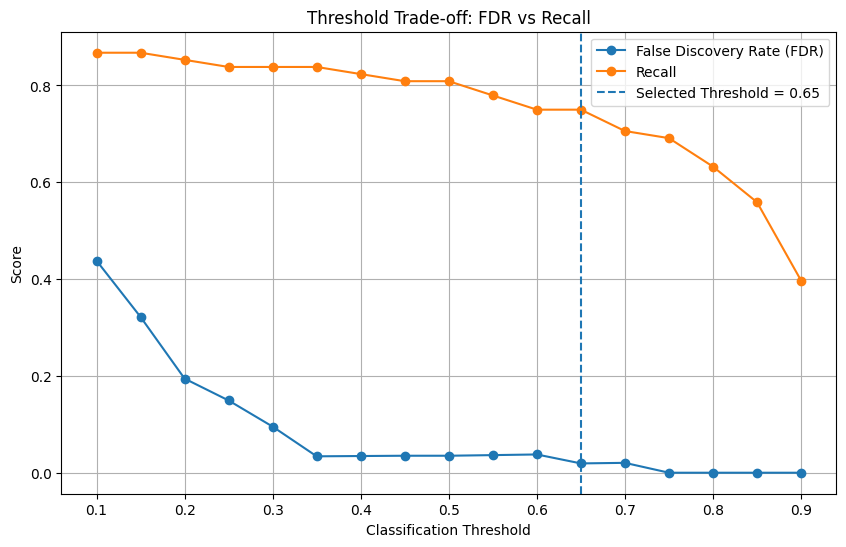

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["FDR"],
    marker="o",
    label="False Discovery Rate (FDR)"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.axvline(
    x=0.65,
    linestyle="--",
    label="Selected Threshold = 0.65"
)

plt.title("Threshold Trade-off: FDR vs Recall")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest - Default",
        "Random Forest - Tuned"
    ],
    "Threshold": [0.50, 0.65],
    "Precision": [
        precision_score(y_test, y_pred_rf),
        precision_t
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf),
        recall_t
    ],
    "F1": [
        f1_score(y_test, y_pred_rf),
        f1_t
    ],
    "False Positives": [
        2,
        fp_t
    ],
    "False Negatives": [
        13,
        fn_t
    ],
    "FDR": [
        2 / (55 + 2),
        fdr_t
    ]
})

comparison

,Model,Threshold,Precision,Recall,F1,False Positives,False Negatives,FDR
0,Random Forest - Default,0.50,0.964912,0.808824,0.88,2,13,0.035088
1,Random Forest - Tuned,0.65,0.980769,0.750000,0.85,1,17,0.019231


In [20]:
# Clean feature names for XGBoost

X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

X_train_xgb.columns = (
    X_train_xgb.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace(" ", "_", regex=False)
)

X_test_xgb.columns = (
    X_test_xgb.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace(" ", "_", regex=False)
)

print(X_train_xgb.columns.tolist())

['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Temperature_Difference_K', 'Power_W', 'Torque_Wear_Interaction', 'Type_H', 'Type_L', 'Type_M']


In [21]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

# Train using cleaned feature names
xgb_model.fit(X_train_xgb, y_train)

# Probability of Machine Failure
y_prob_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

# Default threshold = 0.50
y_pred_xgb = (y_prob_xgb >= 0.50).astype(int)

tn_xgb, fp_xgb, fn_xgb, tp_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
).ravel()

precision_xgb = precision_score(
    y_test, y_pred_xgb, zero_division=0
)

recall_xgb = recall_score(
    y_test, y_pred_xgb, zero_division=0
)

f1_xgb = f1_score(
    y_test, y_pred_xgb, zero_division=0
)

fdr_xgb = (
    fp_xgb / (tp_xgb + fp_xgb)
    if (tp_xgb + fp_xgb) > 0
    else np.nan
)

print("XGBoost Baseline")
print("-" * 40)

print("True Positives :", tp_xgb)
print("False Positives:", fp_xgb)
print("False Negatives:", fn_xgb)
print("True Negatives :", tn_xgb)

print(f"\nPrecision: {precision_xgb:.4f}")
print(f"Recall:    {recall_xgb:.4f}")
print(f"F1 Score:  {f1_xgb:.4f}")
print(f"FDR:       {fdr_xgb:.4f}")
print(f"FDR Percentage: {fdr_xgb * 100:.2f}%")

XGBoost Baseline
----------------------------------------
True Positives : 54
False Positives: 5
False Negatives: 14
True Negatives : 1927

Precision: 0.9153
Recall:    0.7941
F1 Score:  0.8504
FDR:       0.0847
FDR Percentage: 8.47%


In [22]:
xgb_threshold_results = []

thresholds = np.arange(0.10, 0.91, 0.05)

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_xgb >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    fdr = (
        fp / (tp + fp)
        if (tp + fp) > 0
        else np.nan
    )

    xgb_threshold_results.append({
        "Threshold": round(threshold, 2),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "FDR": fdr
    })

xgb_threshold_df = pd.DataFrame(
    xgb_threshold_results
)

xgb_threshold_df

,Threshold,TP,FP,FN,TN,Precision,Recall,F1,FDR
0,0.10,59,27,9,1905,0.686047,0.867647,0.766234,0.313953
1,0.15,58,19,10,1913,0.753247,0.852941,0.800000,0.246753
2,0.20,57,11,11,1921,0.838235,0.838235,0.838235,0.161765
3,0.25,57,8,11,1924,0.876923,0.838235,0.857143,0.123077
4,0.30,57,7,11,1925,0.890625,0.838235,0.863636,0.109375
5,0.35,56,5,12,1927,0.918033,0.823529,0.868217,0.081967
6,0.40,55,5,13,1927,0.916667,0.808824,0.859375,0.083333
7,0.45,54,5,14,1927,0.915254,0.794118,0.850394,0.084746
8,0.50,54,5,14,1927,0.915254,0.794118,0.850394,0.084746
9,0.55,53,5,15,1927,0.913793,0.779412,0.841270,0.086207


In [23]:
model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest - Default",
        "Random Forest - Tuned",
        "XGBoost - Default",
        "XGBoost - Low-FDR"
    ],

    "Threshold": [
        0.50,
        0.65,
        0.50,
        0.85
    ],

    "TP": [
        55,
        51,
        54,
        37
    ],

    "FP": [
        2,
        1,
        5,
        1
    ],

    "FN": [
        13,
        17,
        14,
        31
    ],

    "Precision": [
        0.964912,
        0.980769,
        0.915254,
        0.973684
    ],

    "Recall": [
        0.808824,
        0.750000,
        0.794118,
        0.544118
    ],

    "F1": [
        0.880000,
        0.850000,
        0.850394,
        0.698113
    ],

    "FDR": [
        0.035088,
        0.019231,
        0.084746,
        0.026316
    ]
})

model_comparison

,Model,Threshold,TP,FP,FN,Precision,Recall,F1,FDR
0,Random Forest - Default,0.50,55,2,13,0.964912,0.808824,0.880000,0.035088
1,Random Forest - Tuned,0.65,51,1,17,0.980769,0.750000,0.850000,0.019231
2,XGBoost - Default,0.50,54,5,14,0.915254,0.794118,0.850394,0.084746
3,XGBoost - Low-FDR,0.85,37,1,31,0.973684,0.544118,0.698113,0.026316


In [24]:
failure_types = ["TWF", "HDF", "PWF", "OSF", "RNF"]

# Number of failure types active in each observation
df["Failure_Type_Count"] = df[failure_types].sum(axis=1)

print("Number of active failure types per observation:")
print(
    df["Failure_Type_Count"]
    .value_counts()
    .sort_index()
)

print("\nMachine Failure vs Number of Failure Types:")
print(
    pd.crosstab(
        df["Machine failure"],
        df["Failure_Type_Count"]
    )
)

print("\nObservations with multiple failure types:")
print(
    (df["Failure_Type_Count"] > 1).sum()
)

Number of active failure types per observation:
Failure_Type_Count
0    9652
1     324
2      23
3       1
Name: count, dtype: int64

Machine Failure vs Number of Failure Types:
Failure_Type_Count     0    1   2  3
Machine failure                     
0                   9643   18   0  0
1                      9  306  23  1

Observations with multiple failure types:
24


In [25]:
failure_types = ["TWF", "HDF", "PWF", "OSF", "RNF"]

# Features only — no failure outcome columns
X_failure_types = X_encoded.copy()

# Multi-label targets
Y_failure_types = df[failure_types].copy()

print("Features Shape:")
print(X_failure_types.shape)

print("\nTargets Shape:")
print(Y_failure_types.shape)

print("\nPositive cases for each failure type:")
print(Y_failure_types.sum())

print("\nFailure percentages:")
print(
    (Y_failure_types.mean() * 100)
    .round(3)
)

Features Shape:
(10000, 11)

Targets Shape:
(10000, 5)

Positive cases for each failure type:
TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

Failure percentages:
TWF    0.46
HDF    1.15
PWF    0.95
OSF    0.98
RNF    0.19
dtype: float64


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

failure_results = []
failure_models = {}

for failure in failure_types:

    y_failure = Y_failure_types[failure]

    X_train_ft, X_test_ft, y_train_ft, y_test_ft = train_test_split(
        X_failure_types,
        y_failure,
        test_size=0.20,
        random_state=42,
        stratify=y_failure
    )

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_ft, y_train_ft)

    y_pred_ft = model.predict(X_test_ft)

    tn, fp, fn, tp = confusion_matrix(
        y_test_ft,
        y_pred_ft
    ).ravel()

    precision = precision_score(
        y_test_ft, y_pred_ft, zero_division=0
    )

    recall = recall_score(
        y_test_ft, y_pred_ft, zero_division=0
    )

    f1 = f1_score(
        y_test_ft, y_pred_ft, zero_division=0
    )

    fdr = (
        fp / (tp + fp)
        if (tp + fp) > 0
        else np.nan
    )

    failure_results.append({
        "Failure Type": failure,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "FDR": fdr
    })

    failure_models[failure] = model


failure_results_df = pd.DataFrame(failure_results)

failure_results_df

,Failure Type,TP,FP,FN,TN,Precision,Recall,F1,FDR
0,TWF,0,0,9,1991,0.0,0.000000,0.000000,NaN
1,HDF,19,0,4,1977,1.0,0.826087,0.904762,0.0
2,PWF,19,0,0,1981,1.0,1.000000,1.000000,0.0
3,OSF,19,0,1,1980,1.0,0.950000,0.974359,0.0
4,RNF,0,0,4,1996,0.0,0.000000,0.000000,NaN


In [27]:
probability_analysis = []

for failure in failure_types:

    y_failure = Y_failure_types[failure]

    X_train_ft, X_test_ft, y_train_ft, y_test_ft = train_test_split(
        X_failure_types,
        y_failure,
        test_size=0.20,
        random_state=42,
        stratify=y_failure
    )

    model = failure_models[failure]

    y_prob_ft = model.predict_proba(X_test_ft)[:, 1]

    positive_probs = y_prob_ft[y_test_ft.values == 1]
    negative_probs = y_prob_ft[y_test_ft.values == 0]

    probability_analysis.append({
        "Failure Type": failure,

        "Positive Cases": len(positive_probs),

        "Mean Prob - Positive":
            positive_probs.mean()
            if len(positive_probs) > 0 else np.nan,

        "Max Prob - Positive":
            positive_probs.max()
            if len(positive_probs) > 0 else np.nan,

        "Mean Prob - Negative":
            negative_probs.mean(),

        "Max Prob - Negative":
            negative_probs.max()
    })

probability_df = pd.DataFrame(probability_analysis)

probability_df

,Failure Type,Positive Cases,Mean Prob - Positive,Max Prob - Positive,Mean Prob - Negative,Max Prob - Negative
0,TWF,9,0.057407,0.120000,0.004909,0.273333
1,HDF,23,0.750000,0.950000,0.001300,0.153333
2,PWF,19,0.924211,0.996667,0.000784,0.206667
3,OSF,20,0.789333,0.986667,0.001066,0.463333
4,RNF,4,0.026667,0.093333,0.002104,0.076667


In [28]:
failure_threshold_results = []

thresholds = [
    0.01, 0.02, 0.03, 0.05,
    0.07, 0.10, 0.15, 0.20,
    0.30, 0.40, 0.50
]

for failure in failure_types:

    y_failure = Y_failure_types[failure]

    X_train_ft, X_test_ft, y_train_ft, y_test_ft = train_test_split(
        X_failure_types,
        y_failure,
        test_size=0.20,
        random_state=42,
        stratify=y_failure
    )

    model = failure_models[failure]

    y_prob_ft = model.predict_proba(X_test_ft)[:, 1]

    for threshold in thresholds:

        y_pred_ft = (
            y_prob_ft >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_test_ft,
            y_pred_ft
        ).ravel()

        precision = precision_score(
            y_test_ft,
            y_pred_ft,
            zero_division=0
        )

        recall = recall_score(
            y_test_ft,
            y_pred_ft,
            zero_division=0
        )

        f1 = f1_score(
            y_test_ft,
            y_pred_ft,
            zero_division=0
        )

        fdr = (
            fp / (tp + fp)
            if (tp + fp) > 0
            else np.nan
        )

        failure_threshold_results.append({
            "Failure Type": failure,
            "Threshold": threshold,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "FDR": fdr
        })

failure_threshold_df = pd.DataFrame(
    failure_threshold_results
)

failure_threshold_df

,Failure Type,Threshold,TP,FP,FN,Precision,Recall,F1,FDR
0,TWF,0.01,7,149,2,0.044872,0.777778,0.084848,0.955128
1,TWF,0.02,6,110,3,0.051724,0.666667,0.096000,0.948276
2,TWF,0.03,6,93,3,0.060606,0.666667,0.111111,0.939394
3,TWF,0.05,5,66,4,0.070423,0.555556,0.125000,0.929577
4,TWF,0.07,4,47,5,0.078431,0.444444,0.133333,0.921569
5,TWF,0.10,2,28,7,0.066667,0.222222,0.102564,0.933333
6,TWF,0.15,0,12,9,0.000000,0.000000,0.000000,1.000000
7,TWF,0.20,0,5,9,0.000000,0.000000,0.000000,1.000000
8,TWF,0.30,0,0,9,0.000000,0.000000,0.000000,NaN
9,TWF,0.40,0,0,9,0.000000,0.000000,0.000000,NaN


In [29]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance

,Feature,Importance
0,Torque_Wear_Interaction,0.212689
1,Power [W],0.210460
2,Rotational speed [rpm],0.155098
3,Torque [Nm],0.134075
4,Temperature Difference [K],0.116378
5,Tool wear [min],0.058685
6,Air temperature [K],0.039936
7,Process temperature [K],0.036548
8,Type_L,0.018685
9,Type_M,0.011888


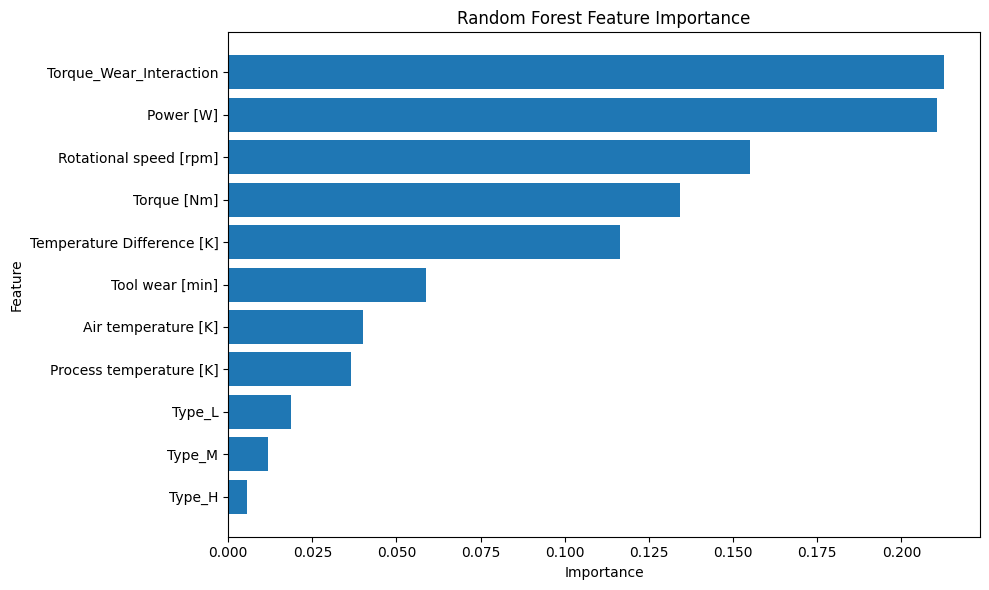

In [30]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [31]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    scoring="precision",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_result.importances_mean
})

permutation_df = (
    permutation_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

permutation_df

,Feature,Importance
0,Rotational speed [rpm],0.319120
1,Temperature Difference [K],0.268543
2,Torque_Wear_Interaction,0.226111
3,Power [W],0.210980
4,Type_L,0.039994
5,Type_M,0.011645
6,Tool wear [min],0.002648
7,Torque [Nm],0.001411
8,Type_H,0.000000
9,Process temperature [K],-0.003532


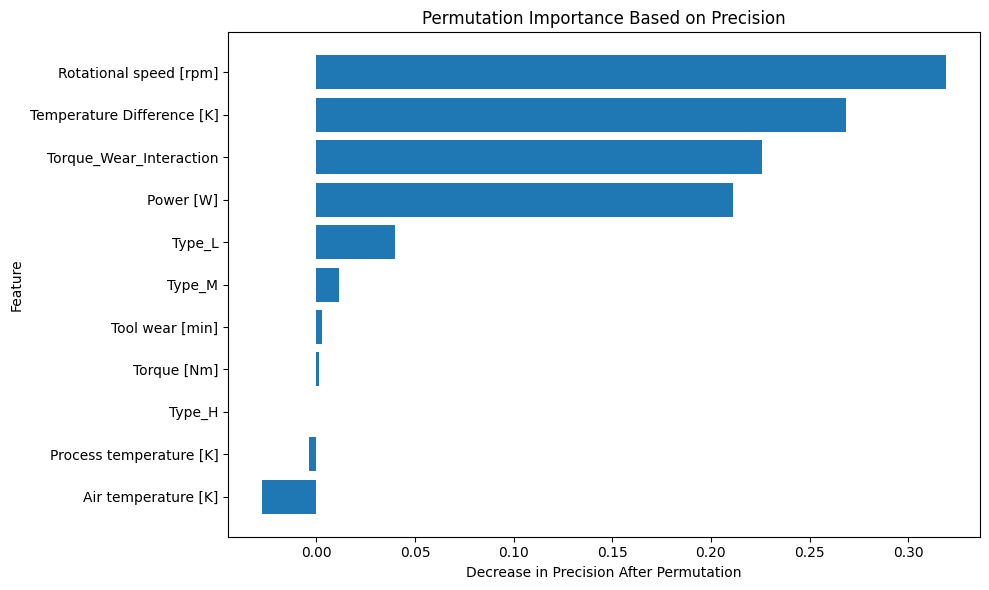

In [32]:
plt.figure(figsize=(10, 6))

plt.barh(
    permutation_df["Feature"],
    permutation_df["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Permutation Importance Based on Precision")
plt.xlabel("Decrease in Precision After Permutation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [33]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary
X_train_final, X_temp, y_train_final, y_temp = train_test_split(
    X_encoded,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: 15% validation, 15% test
X_val, X_test_final, y_val, y_test_final = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train Shape:", X_train_final.shape)
print("Validation Shape:", X_val.shape)
print("Test Shape:", X_test_final.shape)

print("\nTrain target:")
print(y_train_final.value_counts())

print("\nValidation target:")
print(y_val.value_counts())

print("\nTest target:")
print(y_test_final.value_counts())

Train Shape: (7000, 11)
Validation Shape: (1500, 11)
Test Shape: (1500, 11)

Train target:
Machine failure
0    6763
1     237
Name: count, dtype: int64

Validation target:
Machine failure
0    1449
1      51
Name: count, dtype: int64

Test target:
Machine failure
0    1449
1      51
Name: count, dtype: int64


In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train ONLY on training data
rf_final.fit(
    X_train_final,
    y_train_final
)

# Get probabilities ONLY for validation data
y_val_prob = rf_final.predict_proba(X_val)[:, 1]

print("Final Random Forest trained successfully.")
print("Training samples:", len(X_train_final))
print("Validation samples:", len(X_val))
print("Validation failure probabilities:", y_val_prob[:10])

Final Random Forest trained successfully.
Training samples: 7000
Validation samples: 1500
Validation failure probabilities: [0.00333333 0.         0.         0.         0.         0.
 0.         0.         0.         0.00666667]


In [35]:
validation_threshold_results = []

thresholds = np.arange(0.10, 0.91, 0.05)

for threshold in thresholds:

    y_val_pred = (
        y_val_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_val_pred
    ).ravel()

    precision = precision_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    fdr = (
        fp / (tp + fp)
        if (tp + fp) > 0
        else np.nan
    )

    validation_threshold_results.append({
        "Threshold": round(threshold, 2),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "FDR": fdr
    })

validation_threshold_df = pd.DataFrame(
    validation_threshold_results
)

validation_threshold_df

,Threshold,TP,FP,FN,TN,Precision,Recall,F1,FDR
0,0.10,45,35,6,1414,0.562500,0.882353,0.687023,0.437500
1,0.15,45,21,6,1428,0.681818,0.882353,0.769231,0.318182
2,0.20,44,12,7,1437,0.785714,0.862745,0.822430,0.214286
3,0.25,44,9,7,1440,0.830189,0.862745,0.846154,0.169811
4,0.30,44,8,7,1441,0.846154,0.862745,0.854369,0.153846
5,0.35,44,6,7,1443,0.880000,0.862745,0.871287,0.120000
6,0.40,44,6,7,1443,0.880000,0.862745,0.871287,0.120000
7,0.45,44,3,7,1446,0.936170,0.862745,0.897959,0.063830
8,0.50,43,2,8,1447,0.955556,0.843137,0.895833,0.044444
9,0.55,42,2,9,1447,0.954545,0.823529,0.884211,0.045455


In [36]:
# Locked threshold selected using validation data
final_threshold = 0.70

# Predict probabilities on the untouched final test set
y_test_prob_final = rf_final.predict_proba(
    X_test_final
)[:, 1]

# Apply the locked threshold
y_test_pred_final = (
    y_test_prob_final >= final_threshold
).astype(int)

# Confusion matrix
tn_final, fp_final, fn_final, tp_final = confusion_matrix(
    y_test_final,
    y_test_pred_final
).ravel()

# Metrics
accuracy_final = accuracy_score(
    y_test_final,
    y_test_pred_final
)

precision_final = precision_score(
    y_test_final,
    y_test_pred_final,
    zero_division=0
)

recall_final = recall_score(
    y_test_final,
    y_test_pred_final,
    zero_division=0
)

f1_final = f1_score(
    y_test_final,
    y_test_pred_final,
    zero_division=0
)

fdr_final = (
    fp_final / (tp_final + fp_final)
    if (tp_final + fp_final) > 0
    else np.nan
)

print("FINAL RANDOM FOREST TEST RESULTS")
print("=" * 45)
print(f"Locked Threshold : {final_threshold}")

print("\nConfusion Matrix")
print("-" * 45)
print("True Positives  :", tp_final)
print("False Positives :", fp_final)
print("False Negatives :", fn_final)
print("True Negatives  :", tn_final)

print("\nPerformance")
print("-" * 45)
print(f"Accuracy  : {accuracy_final:.4f}")
print(f"Precision : {precision_final:.4f}")
print(f"Recall    : {recall_final:.4f}")
print(f"F1 Score  : {f1_final:.4f}")
print(f"FDR       : {fdr_final:.4f}")
print(f"FDR (%)   : {fdr_final * 100:.2f}%")

FINAL RANDOM FOREST TEST RESULTS
Locked Threshold : 0.7

Confusion Matrix
---------------------------------------------
True Positives  : 36
False Positives : 0
False Negatives : 15
True Negatives  : 1449

Performance
---------------------------------------------
Accuracy  : 0.9900
Precision : 1.0000
Recall    : 0.7059
F1 Score  : 0.8276
FDR       : 0.0000
FDR (%)   : 0.00%


## Final Model Evaluation

The final Random Forest model was trained using 70% of the dataset, while
15% was reserved for validation and 15% for final testing.

The classification threshold was selected exclusively using the validation
set to reduce false alarms. A threshold of **0.70** was selected as an
operating point that prioritizes a low False Discovery Rate (FDR).

### Final Test Results

- Accuracy: **99.00%**
- Precision: **100.00%**
- Recall: **70.59%**
- F1 Score: **82.76%**
- False Positives: **0**
- False Negatives: **15**
- False Discovery Rate (FDR): **0.00%**

The model produced no false-positive maintenance alerts on the held-out
test set. However, this conservative operating threshold reduced recall,
with 15 of the 51 actual machine failures not detected.

This demonstrates the industrial trade-off between minimizing costly
false maintenance alarms and maintaining sufficient failure detection.

### Time-to-Failure Limitation

A Time-to-Failure / Remaining Useful Life regression model was considered
as an extension of this project. However, the AI4I dataset does not provide
a clearly defined longitudinal run-to-failure history for individual
machines or a ground-truth remaining useful life target.

Therefore, an artificial RUL target was not constructed from row order or
UDI, as this could create a misleading regression problem.

A future extension could use a run-to-failure dataset such as a
machine-level degradation time series with an explicitly defined RUL target.

<Figure size 700x600 with 0 Axes>

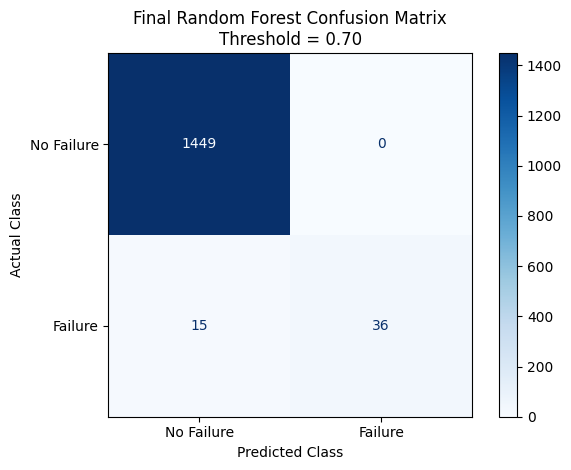

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test_final,
    y_test_pred_final,
    display_labels=["No Failure", "Failure"],
    values_format="d",
    cmap="Blues"
)

plt.title(
    "Final Random Forest Confusion Matrix\n"
    "Threshold = 0.70"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()